In [ ]:
import pandas as pd

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
sns.set_style("darkgrid")

In [4]:
# Studying the divergence of defaulted and non-defaulted observations
# based on their estimated probabilities of default (PD)
# involves analyzing how well the estimated probabilities separate the two groups.
# This is a critical step in evaluating the performance of credit scoring models.

In [5]:
# Load the saved model
rf = joblib.load('rf_model.joblib')  # Load the trained Random Forest model

# Load the data
data = joblib.load('data.joblib')  # Load the dataset
X_test = data['X_test']  # Test features
y_test = data['y_test']  # Test labels (default = 1, non-default = 0)

# Get predicted probabilities for the positive class (defaulted)
y_prob = rf.predict_proba(X_test)[:, 1]  # Extract probabilities for class 1 (defaulted)

# Separate groups based on actual labels
defaulted = y_prob[y_test == 1]  # Predicted probabilities for defaulted
non_defaulted = y_prob[y_test == 0]  # Predicted probabilities for non-defaulted

In [6]:
# Choosing colors
default_color = "orange"   # For defaulters
non_default_color = "blue" # For non-defaulters

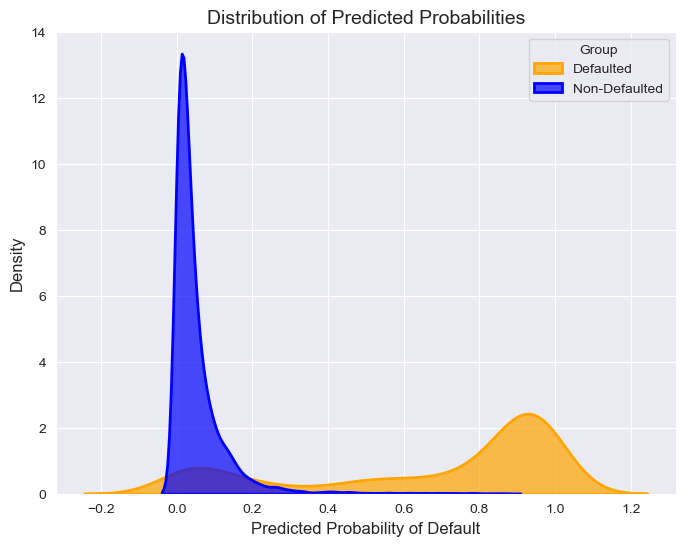

In [7]:
# Distribution Analysis

# Plot the distribution of predicted probabilities for defaulted and non-defaulted groups
plt.figure(figsize=(8, 6))

# KDE plots for defaulted and non-defaulted groups
sns.kdeplot(defaulted, color=default_color, fill=True, alpha=0.7, label='Defaulted', linewidth=2)
sns.kdeplot(non_defaulted, color=non_default_color, fill=True, alpha=0.7, label='Non-Defaulted', linewidth=2)

# Add title and labels
plt.title('Distribution of Predicted Probabilities', fontsize=14)
plt.xlabel('Predicted Probability of Default', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add legend
plt.legend(title='Group', fontsize=10)
plt.show()

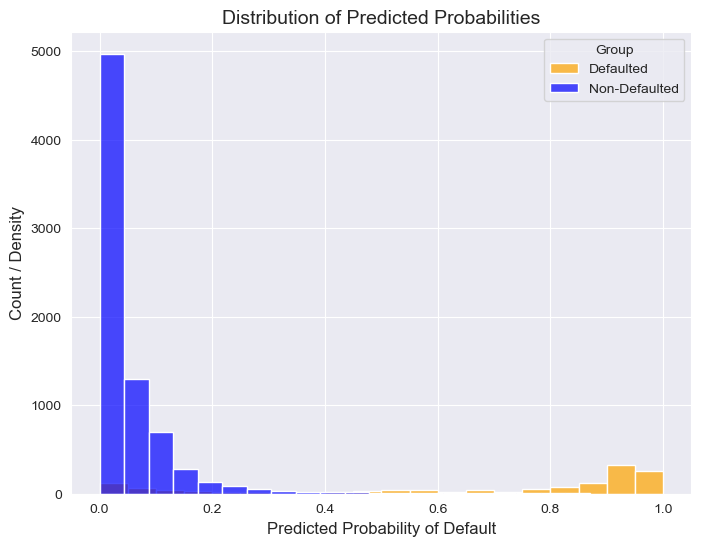

In [8]:
# Plot the distribution of predicted probabilities for defaulted and non-defaulted groups
plt.figure(figsize=(8, 6))

# Histograms for defaulted and non-defaulted groups
sns.histplot(defaulted, color=default_color, alpha=0.7, label='Defaulted', bins=20)
sns.histplot(non_defaulted, color=non_default_color, alpha=0.7, label='Non-Defaulted', bins=20)

## Histograms with density plots for defaulted and non-defaulted groups
#sns.histplot(defaulted, color='red', alpha=0.5, label='Defaulted', bins=30, kde=True, line_kws={'linewidth': 2})
#sns.histplot(non_defaulted, color='blue', alpha=0.5, label='Non-Defaulted', bins=30, kde=True, line_kws={'linewidth': 2})


# Add title and labels
plt.title('Distribution of Predicted Probabilities', fontsize=14)
plt.xlabel('Predicted Probability of Default', fontsize=12)
plt.ylabel('Count / Density', fontsize=12)

# Add legend
plt.legend(title='Group', fontsize=10)
plt.show()

In [9]:
# Create a DataFrame with two columns: y_test and y_prob
df = pd.DataFrame({'y_test': y_test.reset_index(drop=True), 'y_prob': y_prob})

In [10]:
df

,y_test,y_prob
0,0,0.01
1,0,0.06
2,0,0.02
3,0,0.14
4,1,0.98
...,...,...
8995,1,0.95
8996,1,0.89
8997,0,0.02
8998,0,0.01


In [11]:
# pip install scikit-plot

In [12]:
from scikitplot.metrics import plot_ks_statistic

In [13]:
# The KS Statistic plot, also known as the Kolmogorov-Smirnov plot,
# is a graphical tool used to compare the cumulative distribution functions (CDFs) of two or more datasets.
# In this case, it compares the CDFs of "Non-Defaulted" and "Defaulted" observations.

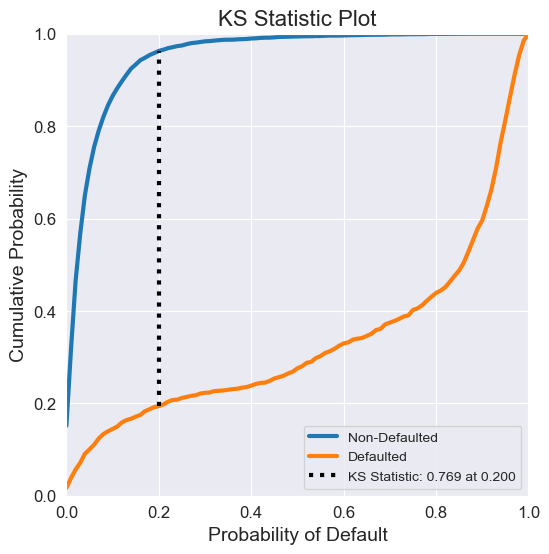

In [14]:
y_orig = df['y_test']
y_prob = pd.DataFrame({'Class 0': 1-df['y_prob'], 'Class 1': df['y_prob']})

ax=plot_ks_statistic(y_orig, y_prob, figsize=(8, 6))

plt.gca().set_aspect('equal', 'box')
plt.ylabel('Cumulative Probability', fontsize = 14)
plt.xlabel('Probability of Default', fontsize = 14)
handles, labels = ax.get_legend_handles_labels()
labels[0] = 'Non-Defaulted'
labels[1] = 'Defaulted'
ax.legend(handles, labels, loc='lower right', fontsize = 10)
plt.title('KS Statistic Plot', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=12)

In [15]:
# Key Elements of the Plot:

# X-axis: Represents the probability of default.
# Y-axis: Represents the cumulative probability of default.
# Non-Defaulted Curve: This curve shows the cumulative probability of default for observations that did not default.
# Defaulted Curve: This curve shows the cumulative probability of default for observations that defaulted.
# KS Statistic: The vertical distance between the two curves at their farthest point.

In [16]:
# The KS Statistic plot visually compares the cumulative probabilities of default for two groups.
# A higher KS Statistic value indicates better model performance in distinguishing between the two groups.
# The KS Statistic of 0.769 suggests a strong ability to differentiate between non-defaulters and defaulters.